In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3    # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print("".join(itos[i] for i in context), "--->", itos[ix])
        context = context[1:] + [ix]    # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
C = torch.randn((27, 2))
# if we want the embeddings for the 5th character
print(C[5])
# previously we did a one-hot for 5 with 27 classes and multiplied it with C to get our 5th row

tensor([-0.9340,  1.1922])


In [8]:
# indexing in pytorch can work with multi dimentional indexing.
# C[[5, 6, 7]]
# C[torch.tensor([5, 6, 7])]
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [9]:
'''
We have our embeddings which is our first layer.
Lets build the hidden layer.

Number of inputs = 6
We have 2 dimentional embeddings and we have 3 of them for a sample. So 3 * 2 = 6

And for the number of neurons, lets have 100

So the weight matrix will be 6 * 100
And the bias would be of size 100, 1 for each neuron
'''
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [10]:
'''
Now, normally we would do
emb @ W1 + b1
But since we have dimentions of 3 x 2 in emb, this won't work

We need to find a way to somehow concatenate our emb to become 36 x 6 to achieve it.
torch comes with so many utilities and one of them is torch.cat
'''
torch.cat((emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]), 1).shape

torch.Size([32, 6])

In [11]:
'''
But the block size which is set as 3 can change
torch.unbind comes to rescue - removes a dimention from tensor and returns the slices in a tuple
'''
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [12]:
'''
There is a much efficient way to achieve the same result in tensor, which is tensor.view

Each tensor maintains a underlying storage of all the numbers in a single dimentional array which can be fetched with

x = torch.tensor([[1, 2, 3], [4, 5, 6]])
x.storage()

tensor uses various variables like shape, etc., to interpret this array in the set shape

tensor.view takes takes any desired shape and returns the respective interpretation
x.view(3, 2) -> 3 rows and 2 cols
It can take any dimentions, only condition the product of the shape should be equal to the total numbers

The reason it's more efficient than torch.cat is cat creates an entire new tensor with new values, thus exhausting memory
whereas view uses the same underlying storage of elements and just modifies the dimentions, no additional memory used

By passing -1 as one of dimentions allows torch to automatically detect the dimention value
'''
emb.view(-1, 6).shape

torch.Size([32, 6])

In [13]:
'''
remember broadcasting in torch tensors for this addition of b1
emb.view(-1, 6) @ W1  ->  32, 100
b1                    ->  100
=> 32, 100
    1, 100
So the addition will be like, 32 copies of b1, each copy superimposed on each row of 32 x 100 and made addition
which is what we want

broadcasting is like BODMAS for tensors
'''
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape

torch.Size([32, 100])

In [14]:
'''
Now for the output layer, and the output is called logits.

Since we have 27 characters, we will have 27 neurons.
And for each neuron will receive inputs from the hidden layer neurons which are 100 in numbers.

So the weight matrix would be 100 x 27
And same as before, the biases would be of size 27, one to each neuron
'''
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [15]:
logits = h @ W2 + b2  # output
logits.shape

torch.Size([32, 27])

In [16]:
'''
Now we do exactly as we did in our previous lesson, exponentiate and calculate probability distribution
'''
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
print(prob[0].sum())
prob.shape

tensor(1.0000)


torch.Size([32, 27])

In [17]:
'''
loss calculation
we have 32 outputs in Y
we have 32 prob. dist. for the inputs X
we pluck the prob of the expected output using Y from the distribution
we log them, take mean of them and negate it to get our negative loss likelihood as we saw before
'''
print(prob[torch.arange(32), Y])
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor([9.9091e-09, 2.1721e-05, 2.3662e-10, 4.6505e-06, 3.1329e-07, 1.8363e-04,
        9.4126e-09, 1.6169e-07, 8.6601e-10, 1.0078e-06, 2.3093e-04, 9.9981e-01,
        2.8547e-12, 1.0276e-05, 3.6159e-06, 5.1996e-04, 3.4763e-05, 5.7469e-06,
        3.3610e-05, 1.4872e-09, 1.2426e-06, 7.7132e-03, 9.9751e-01, 1.8735e-08,
        1.0321e-07, 6.6988e-09, 4.1902e-09, 4.5475e-12, 3.1417e-09, 9.5495e-07,
        8.2611e-05, 9.9034e-01])


tensor(13.5907)

In [18]:
# ------------ now made respectable :) ---------------

In [19]:
X.shape, Y.shape    # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [20]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [21]:
sum(p.nelement() for p in parameters)  # number of parameters in total

3481

In [22]:
emb = C[X]  # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = -prob[torch.arange(32), Y].log().mean()
'''
The above 3 lines combined is just a classification, and there is a utility in torch for this
F.cross_entropy

These 3 lines are just to understand what happens and not recommended for actual training because its not efficient
All these operations create new tensors in memory and the backward pass gets even more inefficient along with forward pass

F.cross_entropy handles this in efficiently by clustering these arithmetics so that the passes becomes simple
Its like what we did for 'exp' in our micrograd by breaking down the expression into more arithmetic operations
This is more efficient both mathematically and memory-wise

We get the same loss value by both methods
'''
loss = F.cross_entropy(logits, Y)
loss

tensor(17.7697)

In [23]:
for p in parameters:
    p.requires_grad = True

In [24]:
for _ in range(1000):
    # forward pass
    emb = C[X]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Y)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

0.2561384439468384


In [28]:
'''
Here we can't achieve 0 for loss because, we have 4 different outputs for the input "..." in our dataset.
We can see it from our logits. In torch, tensor.max returns both max values and their respective indices.
We can see this by comparing that indices with our actual output Y

And also the other logits are overfitted because we only took 5 words for our training
'''
print(logits.max(1))
print(Y)

torch.return_types.max(
values=tensor([13.3348, 17.7905, 20.6013, 20.6120, 16.7355, 13.3348, 15.9984, 14.1723,
        15.9146, 18.3614, 15.9396, 20.9265, 13.3348, 17.1089, 17.1319, 20.0601,
        13.3348, 16.5892, 15.1017, 17.0581, 18.5861, 15.9670, 10.8740, 10.6871,
        15.5056, 13.3348, 16.1794, 16.9743, 12.7426, 16.2008, 19.0846, 16.0195],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))
tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])


In [30]:
'''
Lets do it with the entire dataset
'''
# build the dataset

block_size = 3    # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]    # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [72]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [73]:
sum(p.nelement() for p in parameters)  # number of parameters in total

3481

In [74]:
for p in parameters:
    p.requires_grad = True

In [75]:
for _ in range(100):
    # forward pass
    emb = C[X]  # (228146, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (228146, 100)
    logits = h @ W2 + b2  # (228146, 27)
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad

19.505229949951172
17.084495544433594
15.776532173156738
14.833337783813477
14.002594947814941
13.253254890441895
12.579911231994629
11.9830961227417
11.470490455627441
11.051854133605957
10.709586143493652
10.407631874084473
10.127808570861816
9.864365577697754
9.61450481414795
9.37644100189209
9.148946762084961
8.931112289428711
8.722232818603516
8.52175235748291
8.329231262207031
8.144329071044922
7.966794967651367
7.796453952789307
7.633190155029297
7.476911544799805
7.327525615692139
7.18488883972168
7.048795700073242
6.918957233428955
6.795023441314697
6.676608562469482
6.563323974609375
6.454794406890869
6.350673675537109
6.250648498535156
6.154436111450195
6.061790466308594
5.97248649597168
5.886332035064697
5.803150653839111
5.722788333892822
5.6450982093811035
5.569949626922607
5.497217178344727
5.426784038543701
5.35853910446167
5.292378902435303
5.228207111358643
5.165931701660156
5.105471611022949
5.046750545501709
4.989701747894287
4.934264659881592
4.880382537841797
4.82

In [76]:
'''
Since we are doing it on the entire dataset, there is a visible time taken for the optimisation
To address this, what many people do is to do the optimisation with not the entire dataset but in mini batches
mini batch - a small sub set of the dataset
So for a single pass, they use randomly selected mini batch from the dataset. For the next pass, they again do the same.

By doing this, we can achieve our loss reduction in a much faster way.
And because we are doing in mini batches, the quality of our gradient is lower, so the gradient direction is not reliable,
its not the actual gradient direction. But the gradient direction is good enough, even if it estimates with 32 of samples.

It is much better to have an approximate (non-reliable) gradient and then do more steps than to have the exact gradient and do few steps.
'''
for _ in range(100):
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))    # Randomly select 32 indices in 228146 samples
    
    # forward pass
    emb = C[X[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

3.4398298263549805


In [77]:
# let's calculate the loss on the entire dataset
emb = C[X]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Y)
loss.item()

3.1221160888671875

In [78]:
'''
Learning rate optimisation:
Till now we defined learning rate as 0.1 as static. 
We don't know whether to crank it up or down for our NN to perform well. But there is a way.
First we fix a lower bound and upper bound for the learning rate

By trial and error, we found 0.001 and 1 as our bounds
'''
torch.linspace(0.001, 1, 1000)

tensor([0.0010, 0.0020, 0.0030, 0.0040, 0.0050, 0.0060, 0.0070, 0.0080, 0.0090,
        0.0100, 0.0110, 0.0120, 0.0130, 0.0140, 0.0150, 0.0160, 0.0170, 0.0180,
        0.0190, 0.0200, 0.0210, 0.0220, 0.0230, 0.0240, 0.0250, 0.0260, 0.0270,
        0.0280, 0.0290, 0.0300, 0.0310, 0.0320, 0.0330, 0.0340, 0.0350, 0.0360,
        0.0370, 0.0380, 0.0390, 0.0400, 0.0410, 0.0420, 0.0430, 0.0440, 0.0450,
        0.0460, 0.0470, 0.0480, 0.0490, 0.0500, 0.0510, 0.0520, 0.0530, 0.0540,
        0.0550, 0.0560, 0.0570, 0.0580, 0.0590, 0.0600, 0.0610, 0.0620, 0.0630,
        0.0640, 0.0650, 0.0660, 0.0670, 0.0680, 0.0690, 0.0700, 0.0710, 0.0720,
        0.0730, 0.0740, 0.0750, 0.0760, 0.0770, 0.0780, 0.0790, 0.0800, 0.0810,
        0.0820, 0.0830, 0.0840, 0.0850, 0.0860, 0.0870, 0.0880, 0.0890, 0.0900,
        0.0910, 0.0920, 0.0930, 0.0940, 0.0950, 0.0960, 0.0970, 0.0980, 0.0990,
        0.1000, 0.1010, 0.1020, 0.1030, 0.1040, 0.1050, 0.1060, 0.1070, 0.1080,
        0.1090, 0.1100, 0.1110, 0.1120, 

In [79]:
# Lets have exponential distribution
lre = torch.linspace(-3, 0, 1000)  # 10**-3 = 0.001, 10**0 = 1
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [89]:
# Lets do for start
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [90]:
sum(p.nelement() for p in parameters)  # number of parameters in total

3481

In [91]:
for p in parameters:
    p.requires_grad = True

In [87]:
lri = []
lossi = []
for i in range(1000):
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))    # Randomly select 32 indices in 228146 samples
    
    # forward pass
    emb = C[X[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())
print(loss.item())

6.226964950561523


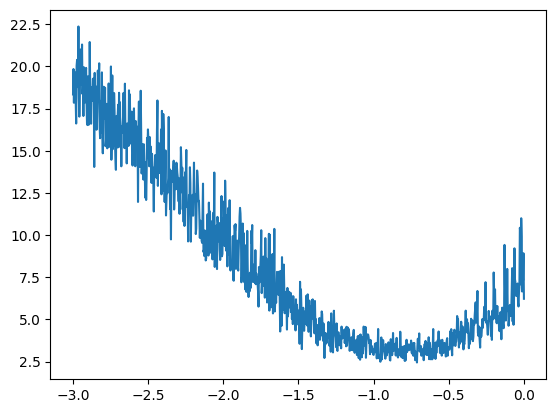

In [88]:
plt.plot(lri, lossi)

In [104]:
# we can see that, the optimum exponent is nearly -1, so learning rate is 0.1 which is our initial one
# After couple of runs of 10000 times, we can make it slightly lower to 0.01 which is called learning decay
# Lets reinitialize and train with 0.1
for i in range(10000):
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))    # Randomly select 32 indices in 228146 samples
    
    # forward pass
    emb = C[X[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = 0.1
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

In [109]:
# let's calculate the loss on the entire dataset
emb = C[X]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.3060, grad_fn=<NllLossBackward0>)

In [156]:
# we have already surpassed our previous bigram model we did before which achieved nearly 2.45 as loss
'''
Our model is a small one with only 3k parameters. We can have as many neurons and there increase our parameters.
It causes our NN to be big which can learn more perfectly and thereby bringing down our loss even close to 0.
But it leads to overfitting. The model just memorized the dataset then. It loses generating capability.

So we need to have three splits of our dataset
training split, dev/validation split, test split
80%, 10%, 10%
training - used to tune the parameters
dev/validation - used to tweek the settings/config of the neural network like no. of neurons, no. of layers, strength of regularization, etc.
test - used to test the model. should be used only few times occationally. Or else, we are just inputting the data we got from testing into our training
'''

# build the dataset

def build_dataset(words):
    block_size = 3  # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]    # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182484, 3]) torch.Size([182484])
torch.Size([22869, 3]) torch.Size([22869])
torch.Size([22793, 3]) torch.Size([22793])


In [111]:
# Lets do from start
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [112]:
for p in parameters:
    p.requires_grad = True

In [114]:
# now we train with training dataset
# first trained 30000 passes with lr 0.1
# then trained 10000 passes with decayed lr 0.01
for i in range(10000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))    # Randomly select 32 indices in 228146 samples
    
    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = 0.1
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
print(loss.item())

1.976590871810913


In [115]:
# Lets evaluate dev loss
emb = C[Xdev]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3415, grad_fn=<NllLossBackward0>)

In [116]:
# Lets see on train dataset
emb = C[Xtr]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.3388, grad_fn=<NllLossBackward0>)

In [ ]:
# we get similar loss on both train and dev sets. This is now an "underfitted model".
# We expect to make performance improvements by scalling up the size of this neural network. Let's do that now.
# experiment: larger hidden layer
# lets make the hidden layer have 300 neurons instead of 100

In [117]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [118]:
sum(p.nelement() for p in parameters)  # number of parameters in total

10281

In [119]:
for p in parameters:
    p.requires_grad = True

In [126]:
for i in range(30000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))    # Randomly select 32 indices in 228146 samples
    
    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = 0.1
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
print(loss.item())

2.5224661827087402


In [127]:
# Lets evaluate dev loss
emb = C[Xdev]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2351, grad_fn=<NllLossBackward0>)

In [128]:
# Lets see on train dataset
emb = C[Xtr]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2267, grad_fn=<NllLossBackward0>)

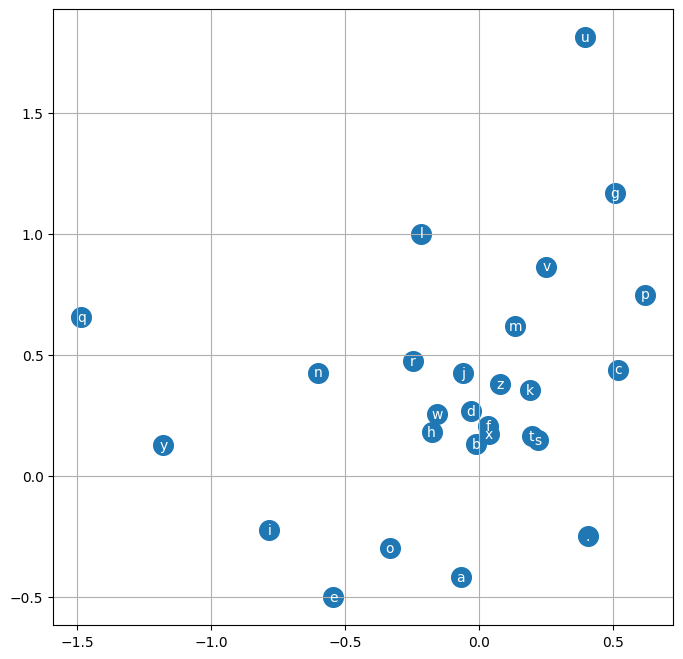

In [129]:
# Seems its not helping. The bottleneck lies in having only 2 dimentions to embed a character
# Lets visualize how our trained embeddings looks like now since its easier to plot 2 dimentions
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [132]:
# experiment: larger embedding size
# Lets have 10 dimentions and 200 neurons of hidden layer

In [133]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [134]:
sum(p.nelement() for p in parameters)  # number of parameters in total

11897

In [135]:
for p in parameters:
    p.requires_grad = True

In [143]:
for i in range(50000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))    # Randomly select 32 indices in 228146 samples
    
    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = 0.1
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
# print(loss.item())

In [144]:
# Lets evaluate dev loss
emb = C[Xdev]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1619, grad_fn=<NllLossBackward0>)

In [145]:
# Lets see on train dataset
emb = C[Xtr]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1243, grad_fn=<NllLossBackward0>)

In [148]:
# We got better results now, but as we see, the train and dev loss gap is getting widened,
# meaning our model is getting deviated towards overfitting
# Like this, we can continue optimizing our neural net more, or change the number of neurons, or even try increasing the block size
# now we have more knobs that we can tune
'''
1. no. of neurons
2. dimentionality of the embeddings
3. block size of the context
4. no. of passes / optimisation
5. learning rate and its decay
6. mini batch size - helps optimize faster
'''
# the above mentioned paper have more methods

'\n1. no. of neurons\n2. dimentionality of the embeddings\n3. block size of the context\n4. no. of passes / optimisation\n5. learning rate and its decay\n6. mini batch size - helps optimize faster\n'

In [149]:
# ------------ now made respectable :) ---------------

In [157]:
Xtr.shape, Ytr.shape  # dataset

(torch.Size([182484, 3]), torch.Size([182484]))

In [163]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [164]:
sum(p.nelement() for p in parameters)  # number of parameters in total

11897

In [165]:
for p in parameters:
    p.requires_grad = True

In [166]:
stepi = []
lossi = []

In [167]:
for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))    # Randomly select 32 indices in 228146 samples
    
    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    # lr = 0.1
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())    # just loss makes the graph to take a vertical downward steep at the start, log10 compressess that steep
# print(loss.item())

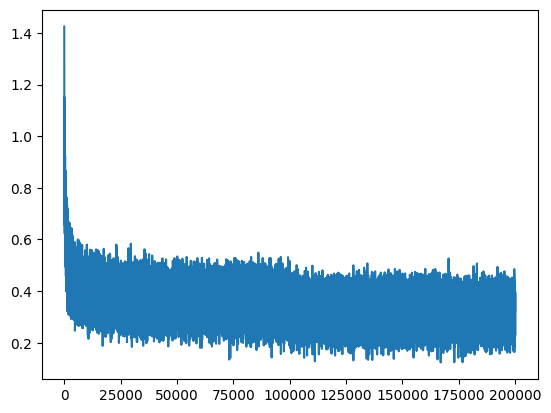

In [168]:
plt.plot(stepi, lossi)

In [171]:
# Lets see on train dataset
emb = C[Xtr]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1270, grad_fn=<NllLossBackward0>)

In [172]:
# Lets evaluate dev loss
emb = C[Xdev]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1680, grad_fn=<NllLossBackward0>)

In [178]:
# sampling from the model

In [182]:
C[torch.tensor([[0, 0, 0]])].shape

torch.Size([1, 3, 10])

In [184]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size  # initialize with all ...
    while True:
        emb = C[torch.tensor([context])]  # (1, block_size, d)  1 -> just sampling for 1
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)  # same pros and cons as F.cross_entropy as above
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carmah.
aab.
hari.
kimilia.
aty.
skansh.
eja.
hube.
deliah.
jareei.
nellaiah.
maiir.
kaleigh.
ham.
joce.
quintis.
lilea.
jadbicoltero.
dearynix.
kaeklinsley.


In [185]:
for _ in range(20):
    out = []
    context = [0] * block_size  # initialize with all ...
    while True:
        emb = C[torch.tensor([context])]  # (1, block_size, d)  1 -> just sampling for 1
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)  # same pros and cons as F.cross_entropy as above
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

daido.
abetteley.
frana.
aseiva.
husya.
samarion.
kylore.
calaira.
nee.
kaadhiah.
zoelei.
jayzhayner.
mollianna.
hexon.
lozbert.
bria.
adee.
tith.
brion.
der.
